In [2]:
import os
import sys
import io
from ctypes import *
import numpy as np
import matplotlib.pyplot as plt
import numpy.ctypeslib
from PIL import Image

from utils import plot_accuracies, plot_losses
from dataset import load_image, load_dataset, shuffle_dataset, z_normalize, display_images

from lib_loader import load_my_lib

path = "../my_lib/target/release/deps/libmy_lib.so"

my_lib = load_my_lib(path)

seed = 42

2024-07-19 23:30:38.979288: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-07-19 23:30:39.016340: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-19 23:30:39.745745: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


X_train shape: (14763, 48, 48, 3)
y_train shape: (14763, 3)
X_test shape: (3700, 48, 48, 3)
y_test shape: (3700, 3)


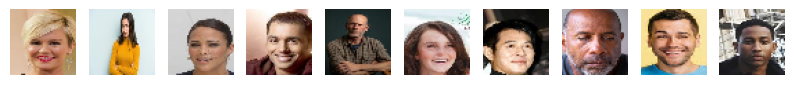

In [2]:
# Exemple d'utilisation
path_to_dataset = '../dataset_upgrade'
image_size = 48  # Vous pouvez ajuster cette taille
X_train, y_train, X_test, y_test = load_dataset(path_to_dataset, image_size)
X_train, y_train = shuffle_dataset(X_train, y_train, seed)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

display_images(X_train, 10)

In [3]:
input_shape = X_train[0].shape 

X_train_flat = X_train.flatten()/255.
X_test_flat = X_test.flatten()/255.

y_train_flat = y_train.flatten()
y_test_flat = y_test.flatten()

In [ ]:
model = my_lib.create_MyCNN(input_shape[0], input_shape[1], input_shape[2])

# Ajout des couches
my_lib.add_conv_layer_MyCNN(model, 16, 3, 1, "Tanh".encode('utf-8'), 0.0, seed)
my_lib.add_maxpooling_layer_MyCNN(model, 2)

my_lib.add_dense_layer_MyCNN(model, 32, "Tanh".encode('utf-8'), 0.0, seed)
my_lib.add_dense_layer_MyCNN(model, 3, "Tanh".encode('utf-8'), 0.0, seed)

# Définir la fonction de perte et l'optimiseur
my_lib.set_optimizer_SGD(model, 0.01)

# Entraînement du modèle
epochs = 100
batch_size = 1
my_lib.train_MyCNN(
                model,
                X_train_flat, y_train_flat,
                X_test_flat, y_test_flat,
                X_train.shape[0],
                X_test.shape[0],  
                input_shape[0], input_shape[1], input_shape[2],
                y_train.shape[1],
                epochs,
                batch_size,
                seed
            )

# Destruction de l'instance de MyCNN
my_lib.destroy_MyCNN(model)

Training starting...
Epoch 0: [==================================================] 100% - Train acc 57.6% - Train loss 0.5495 - Testing...
Epoch 0: Train acc 57.6% - Test acc 63.2% - Test loss 0.4902


In [ ]:
path = "../saved_models/CNN_models/CNN_76/best_model/best_model.json".encode('utf-8')

# Charger le modèle
loaded_model = my_lib.load_MyCNN(path)
if loaded_model:
    print("Model loaded successfully.")
else:
    print("Failed to load model.")

# Prédiction sur le jeu de test avec le modèle chargé
predictions = my_lib.predict_MyCNN(
    loaded_model,
    X_test_flat,
    X_test.shape[0],
    input_shape[0],
    input_shape[1],
    input_shape[2]
)

# Convertir les prédictions en tableau NumPy
predictions = np.ctypeslib.as_array(predictions, shape=(X_test.shape[0], y_test.shape[1]))

# Afficher quelques prédictions pour vérifier
for i in range(10):
    print(f"Prediction: {predictions[i]}, Actual: {y_test[i]}")


In [3]:
import json

def read_metrics(file_path):
    """
    Reads the metrics from a given JSON file and returns them as a dictionary.

    Args:
    - file_path (str): The path to the JSON file containing the metrics.

    Returns:
    - dict: A dictionary containing the metrics.
    """
    try:
        with open(file_path, 'r') as file:
            metrics = json.load(file)
        return metrics
    except FileNotFoundError:
        print(f"File not found: {file_path}")
        return None
    except json.JSONDecodeError:
        print(f"Error decoding JSON from file: {file_path}")
        return None

# Example usage:
file_path = "../saved_models/CNN_models/2024-07-15_11-10-29/metrics.json"
metrics = read_metrics(file_path)
print(metrics)

{'epoch_times': [303, 304, 306], 'test_accuracies': [0.4867762687634024, 0.6683345246604717, 0.6792947343340481], 'test_losses': [0.2063327496052778, 0.1532088671847934, 0.15252417545845487], 'train_accuracies': [0.5657588939872474, 0.643465824444312, 0.6811870567904177], 'train_losses': [0.18680109383890123, 0.16104128615175456, 0.14969083301444108]}


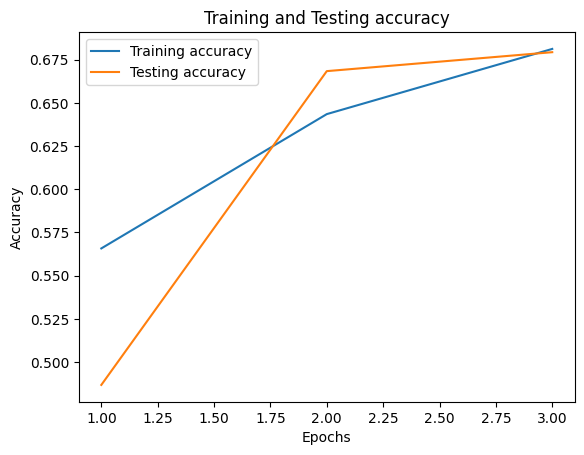

In [11]:
# Fonction pour afficher les courbes de précision
def plot_accuracies(train_accuracies, test_accuracies):
    epochs = range(1, len(train_accuracies) + 1)
    plt.plot(epochs, train_accuracies, label='Training accuracy')
    plt.plot(epochs, test_accuracies, label='Testing accuracy')
    plt.title('Training and Testing accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

# Fonction pour afficher les courbes de pertes
def plot_losses(train_losses, test_losses):
    epochs = range(1, len(train_losses) + 1)
    plt.plot(epochs, train_losses, label='Training loss')
    plt.plot(epochs, test_losses, label='Testing loss')
    plt.title('Training and Testing loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

plot_accuracies(metrics["train_accuracies"], metrics["test_accuracies"])